In [102]:
import numpy as np
import pandas as pd
import os

# 1. Khởi tạo dữ liệu trực tiếp từ bảng 6.3 (Source [3, 4])
regions = [
    "Trung du miền núi phía Bắc", "Đồng bằng sông Hồng", 
    "Bắc Trung Bộ + DH Trung Bộ", "Tây Nguyên", 
    "Đông Nam Bộ", "Đồng bằng sông Cửu Long"
]

data = np.array([
    [57.0, 3.5, 38, 22, 21.5, 0.18, 72, 0.405],
    [152.3, 20.0, 78, 68, 36.8, 0.85, 92, 0.358],
    [87.5, 8.2, 55, 40, 27.5, 0.32, 84, 0.372],
    [68.9, 0.8, 32, 18, 18.2, 0.15, 68, 0.412],
    [158.9, 18.5, 82, 75, 42.5, 0.78, 94, 0.385],
    [80.5, 2.1, 48, 30, 16.8, 0.22, 78, 0.392]
])

# Tiêu chí: Gini là tiêu chí chi phí (False), còn lại là lợi ích (True) [4]
is_benefit = [True, True, True, True, True, True, True, False]

# Trọng số chuyên gia (Source [2])
w = np.array([0.10, 0.10, 0.15, 0.20, 0.15, 0.15, 0.05, 0.10])

# --- THỰC HIỆN CÀI ĐẶT 5 BƯỚC TOPSIS (Source [1, 3, 6-8]) ---

# Bước 1: Chuẩn hóa ma trận quyết định (Vector Normalization) [1]
norm_matrix = data / np.sqrt((data**2).sum(axis=0))

# Bước 2: Xây dựng ma trận chuẩn hóa có trọng số [6]
weighted_matrix = norm_matrix * w

# Bước 3: Xác định lời giải lý tưởng dương (A*) và âm (A-) [7]
a_star = np.where(is_benefit, weighted_matrix.max(axis=0), weighted_matrix.min(axis=0))
a_neg = np.where(is_benefit, weighted_matrix.min(axis=0), weighted_matrix.max(axis=0))

# Bước 4: Tính khoảng cách Euclide (S* và S-) [8]
s_star = np.sqrt(((weighted_matrix - a_star)**2).sum(axis=1))
s_neg = np.sqrt(((weighted_matrix - a_neg)**2).sum(axis=1))

# Bước 5: Tính hệ số gần gũi tương đối (C*) và xếp hạng [3]
c_star = s_neg / (s_star + s_neg)

# 2. Xử lý lưu trữ kết quả theo cấu trúc thư mục Phụ lục F1.4 [5]
# Giả sử bạn đang chạy file từ folder 'notebooks', dùng '..' để lùi lại 'aideom_vn' rồi vào 'outputs'
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "ket_qua_topsis_641.txt")

# Tạo DataFrame để hiển thị và lưu
df_result = pd.DataFrame({
    'Vùng kinh tế': regions,
    'Điểm TOPSIS (Ci*)': c_star
})
df_result['Xếp hạng'] = df_result['Điểm TOPSIS (Ci*)'].rank(ascending=False).astype(int)
df_result = df_result.sort_values(by='Xếp hạng')

# In kết quả ra màn hình (ĐÃ THÊM TIÊU ĐỀ Ở ĐÂY)
print("--- KẾT QUẢ XẾP HẠNG TOPSIS 6 VÙNG KINH TẾ (CÂU 6.4.1) ---")
print(df_result.to_string(index=False))

# Ghi kết quả vào file
with open(output_path, "w", encoding="utf-8") as f:
    f.write("--- KẾT QUẢ XẾP HẠNG TOPSIS 6 VÙNG KINH TẾ (CÂU 6.4.1) ---\n")
    f.write(df_result.to_string(index=False))

print(f"\n[THÔNG BÁO] Kết quả đã được lưu tại: {os.path.abspath(output_path)}")

--- KẾT QUẢ XẾP HẠNG TOPSIS 6 VÙNG KINH TẾ (CÂU 6.4.1) ---
              Vùng kinh tế  Điểm TOPSIS (Ci*)  Xếp hạng
               Đông Nam Bộ           0.940152         1
       Đồng bằng sông Hồng           0.898133         2
Bắc Trung Bộ + DH Trung Bộ           0.359720         3
   Đồng bằng sông Cửu Long           0.171038         4
Trung du miền núi phía Bắc           0.099286         5
                Tây Nguyên           0.031216         6

[THÔNG BÁO] Kết quả đã được lưu tại: D:\aideom_vn\outputs\ket_qua_topsis_641.txt


In [4]:
import numpy as np
import pandas as pd
import os

# 1. Khởi tạo dữ liệu trực tiếp từ Bảng 6.3 trong tài liệu
regions = [
    "Trung du miền núi phía Bắc", "Đồng bằng sông Hồng", 
    "Bắc Trung Bộ + DH Trung Bộ", "Tây Nguyên", 
    "Đông Nam Bộ", "Đồng bằng sông Cửu Long"
]

# Ma trận X (x_ij) từ Bảng 6.3
data = np.array([
    [57.0, 3.5, 38, 22, 21.5, 0.18, 72, 0.405],
    [152.3, 20.0, 78, 68, 36.8, 0.85, 92, 0.358],
    [87.5, 8.2, 55, 40, 27.5, 0.32, 84, 0.372],
    [68.9, 0.8, 32, 18, 18.2, 0.15, 68, 0.412],
    [158.9, 18.5, 82, 75, 42.5, 0.78, 94, 0.385],
    [80.5, 2.1, 48, 30, 16.8, 0.22, 78, 0.392]
])

# Tiêu chí: Gini là chi phí (False), còn lại là lợi ích (True)
is_benefit = [True, True, True, True, True, True, True, False]

# Trọng số chuyên gia từ câu 6.4.1
w_expert = np.array([0.10, 0.10, 0.15, 0.20, 0.15, 0.15, 0.05, 0.10])

# --- HÀM TÍNH TRỌNG SỐ ENTROPY (Theo gợi ý mã nguồn trang 59-60) ---
def entropy_weights(X):
    # Bước 1: Chuẩn hóa ma trận xác suất Pij
    P = X / X.sum(axis=0)
    # Bước 2: Tính hằng số k = 1/ln(n) với n=6 vùng
    k = 1.0 / np.log(len(X))
    # Bước 3: Tính Entropy E và độ phân tán d
    E = -k * np.nansum(P * np.log(P + 1e-12), axis=0)
    d = 1 - E
    # Bước 4: Trọng số khách quan w = d / sum(d)
    return d / d.sum()

# --- HÀM THỰC HIỆN TOPSIS (Quy trình 5 bước trang 51-55) ---
def run_topsis(X, weights, benefit_flags):
    # Bước 1: Chuẩn hóa vector
    R = X / np.sqrt((X**2).sum(axis=0))
    # Bước 2: Ma trận chuẩn hóa có trọng số
    V = R * weights
    # Bước 3: Lời giải lý tưởng dương (A*) và âm (A-)
    A_star = np.where(benefit_flags, V.max(axis=0), V.min(axis=0))
    A_neg  = np.where(benefit_flags, V.min(axis=0), V.max(axis=0))
    # Bước 4: Tính khoảng cách Euclide
    S_star = np.sqrt(((V - A_star)**2).sum(axis=1))
    S_neg  = np.sqrt(((V - A_neg )**2).sum(axis=1))
    # Bước 5: Tính hệ số gần gũi Ci*
    return S_neg / (S_star + S_neg)

# --- THỰC THI TÍNH TOÁN ---
w_entropy = entropy_weights(data)

# Tính điểm số cho cả 2 phương pháp
score_expert = run_topsis(data, w_expert, is_benefit)
score_entropy = run_topsis(data, w_entropy, is_benefit)

# Tạo bảng so sánh
df_compare = pd.DataFrame({
    'Vùng kinh tế': regions,
    'Hạng (Chuyên gia 6.4.1)': pd.Series(score_expert).rank(ascending=False).astype(int),
    'Hạng (Entropy 6.4.2)': pd.Series(score_entropy).rank(ascending=False).astype(int),
    'Điểm Ci* (6.4.1)': score_expert,
    'Điểm Ci* (6.4.2)': score_entropy
}).sort_values('Hạng (Entropy 6.4.2)')

# --- XỬ LÝ LƯU TRỮ (Theo Phụ lục F1.4) ---
# Lùi ra khỏi folder notebooks để vào folder outputs
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "ket_qua_topsis_642.txt")

# In kết quả ra màn hình
print("--- SO SÁNH KẾT QUẢ XẾP HẠNG TOPSIS: CHUYÊN GIA VS ENTROPY ---")
print(df_compare.to_string(index=False))

# Ghi kết quả vào file
with open(output_file, "w", encoding="utf-8") as f:
    f.write("--- SO SÁNH KẾT QUẢ XẾP HẠNG TOPSIS: CHUYÊN GIA (6.4.1) VS ENTROPY (6.4.2) ---\n")
    f.write(f"Trọng số Entropy tính được: {w_entropy}\n\n")
    f.write(df_compare.to_string(index=False))

print(f"\n[THÔNG BÁO] Kết quả đã được lưu tại: {os.path.abspath(output_file)}")

--- SO SÁNH KẾT QUẢ XẾP HẠNG TOPSIS: CHUYÊN GIA VS ENTROPY ---
              Vùng kinh tế  Hạng (Chuyên gia 6.4.1)  Hạng (Entropy 6.4.2)  Điểm Ci* (6.4.1)  Điểm Ci* (6.4.2)
       Đồng bằng sông Hồng                        2                     1          0.898133          0.968977
               Đông Nam Bộ                        1                     2          0.940152          0.920288
Bắc Trung Bộ + DH Trung Bộ                        3                     3          0.359720          0.361901
Trung du miền núi phía Bắc                        5                     4          0.099286          0.124793
   Đồng bằng sông Cửu Long                        4                     5          0.171038          0.089692
                Tây Nguyên                        6                     6          0.031216          0.011642

[THÔNG BÁO] Kết quả đã được lưu tại: D:\aideom_vn\outputs\ket_qua_topsis_642.txt


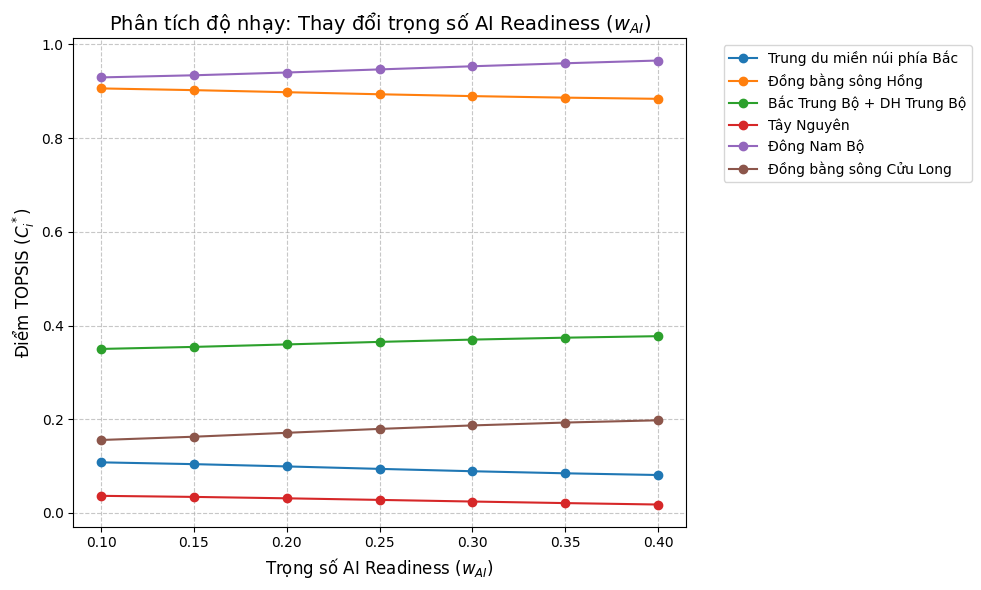

--- XẾP HẠNG TẠI CÁC MỨC TRỌNG SỐ AI KHÁC NHAU ---

Khi w_AI = 0.10:
Đông Nam Bộ                   1.0
Đồng bằng sông Hồng           2.0
Bắc Trung Bộ + DH Trung Bộ    3.0
Name: 0.1, dtype: float64

Khi w_AI = 0.25:
Đông Nam Bộ                   1.0
Đồng bằng sông Hồng           2.0
Bắc Trung Bộ + DH Trung Bộ    3.0
Name: 0.25, dtype: float64

Khi w_AI = 0.40:
Đông Nam Bộ                   1.0
Đồng bằng sông Hồng           2.0
Bắc Trung Bộ + DH Trung Bộ    3.0
Name: 0.4, dtype: float64


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Khởi tạo dữ liệu từ Bảng 6.3
regions = [
    "Trung du miền núi phía Bắc", "Đồng bằng sông Hồng", 
    "Bắc Trung Bộ + DH Trung Bộ", "Tây Nguyên", 
    "Đông Nam Bộ", "Đồng bằng sông Cửu Long"
]

data = np.array([
    [57.0, 3.5, 38, 22, 21.5, 0.18, 72, 0.405],
    [152.3, 20.0, 78, 68, 36.8, 0.85, 92, 0.358],
    [87.5, 8.2, 55, 40, 27.5, 0.32, 84, 0.372],
    [68.9, 0.8, 32, 18, 18.2, 0.15, 68, 0.412],
    [158.9, 18.5, 82, 75, 42.5, 0.78, 94, 0.385],
    [80.5, 2.1, 48, 30, 16.8, 0.22, 78, 0.392]
])

is_benefit = [True, True, True, True, True, True, True, False]
# Trọng số gốc (w[3] là AI Readiness = 0.20)
w_original = np.array([0.10, 0.10, 0.15, 0.20, 0.15, 0.15, 0.05, 0.10])

def run_topsis(X, weights, benefit_flags):
    R = X / np.sqrt((X**2).sum(axis=0))
    V = R * weights
    A_star = np.where(benefit_flags, V.max(axis=0), V.min(axis=0))
    A_neg  = np.where(benefit_flags, V.min(axis=0), V.max(axis=0))
    S_star = np.sqrt(((V - A_star)**2).sum(axis=1))
    S_neg  = np.sqrt(((V - A_neg )**2).sum(axis=1))
    return S_neg / (S_star + S_neg)

# 2. PHÂN TÍCH ĐỘ NHẠY
# ĐIỀU CHỈNH LỖI: Làm tròn mảng số thực đến 2 chữ số thập phân
w_ai_range = np.round(np.arange(0.10, 0.45, 0.05), 2) 

sensitivity_results = []

for w_ai in w_ai_range:
    # Sao chép bộ trọng số gốc
    w_new = w_original.copy()
    
    # Tính tổng các trọng số còn lại (không phải AI)
    idx_ai = 3
    sum_others = np.sum(w_original) - w_original[idx_ai]
    
    # Điều chỉnh các trọng số còn lại để tổng = 1
    factor = (1.0 - w_ai) / sum_others
    for i in range(len(w_new)):
        if i == idx_ai:
            w_new[i] = w_ai
        else:
            w_new[i] = w_original[i] * factor
            
    # Chạy TOPSIS với bộ trọng số mới
    scores = run_topsis(data, w_new, is_benefit)
    sensitivity_results.append(scores)

# Chuyển kết quả sang DataFrame để dễ vẽ đồ thị
df_sensitivity = pd.DataFrame(sensitivity_results, columns=regions, index=w_ai_range)

# 3. VẼ BIỂU ĐỒ PHÂN TÍCH ĐỘ NHẠY
plt.figure(figsize=(10, 6))
for region in regions:
    plt.plot(df_sensitivity.index, df_sensitivity[region], marker='o', label=region)

plt.title("Phân tích độ nhạy: Thay đổi trọng số AI Readiness ($w_{AI}$)", fontsize=14)
plt.xlabel("Trọng số AI Readiness ($w_{AI}$)", fontsize=12)
plt.ylabel("Điểm TOPSIS ($C_i^*$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 4. LƯU KẾT QUẢ
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "sensitivity_analysis_643.png"))
df_sensitivity.to_csv(os.path.join(output_dir, "sensitivity_data_643.csv"))

plt.show()

# 5. IN BẢNG XẾP HẠNG
print("--- XẾP HẠNG TẠI CÁC MỨC TRỌNG SỐ AI KHÁC NHAU ---")
for w in [0.10, 0.25, 0.40]:
    # Do index đã được làm tròn đúng, lệnh loc[w] sẽ hoạt động bình thường
    rank = df_sensitivity.loc[w].rank(ascending=False).sort_values()
    print(f"\nKhi w_AI = {w:.2f}:")
    print(rank.head(3))

In [99]:
import numpy as np
import pandas as pd

# =============================================================================
# BƯỚC 1: KHỞI TẠO DANH SÁCH TIÊU CHÍ VÀ MA TRẬN
# =============================================================================
# C1: GRDP, C2: FDI, C3: Digital, C4: AI Ready, C5: LĐ Đào tạo, C6: R&D, C7: Internet, C8: Gini
criteria = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']
n = len(criteria)

# Khởi tạo ma trận đơn vị 8x8 (đường chéo chính mặc định sẵn bằng 1)
A = np.eye(n)

# =============================================================================
# BƯỚC 2: ĐIỀN GIÁ TRỊ SO SÁNH CẶP (ĐÃ QUY ĐỔI SANG CHỈ MỤC TOÁN HỌC TỪ 0 ĐẾN 7)
# Quy đổi chuẩn Python: C1=0, C2=1, C3=2, C4=3, C5=4, C6=5, C7=6, C8=7
# Thang đo Saaty: 1-Bằng nhau, 3-Hơi quan trọng, 5-Quan trọng rõ, 7-Rất quan trọng, 9-Tuyệt đối.
# =============================================================================

# --- Hàng C1 (Chỉ mục 0) so với các tiêu chí khác ---
A[0, 1] = 1    # C1 vs C2
A[0, 2] = 1/3    # C1 vs C3
A[0, 3] = 1/5    # C1 vs C4
A[0, 4] = 1/3    # C1 vs C5
A[0, 5] = 1/3    # C1 vs C6
A[0, 6] = 3    # C1 vs C7
A[0, 7] = 1    # C1 vs C8

# --- Hàng C2 (Chỉ mục 1) so với các tiêu chí khác ---
A[1, 2] = 1/2    # C2 vs C3
A[1, 3] = 1/4    # C2 vs C4
A[1, 4] = 1/2    # C2 vs C5
A[1, 5] = 1/2    # C2 vs C6
A[1, 6] = 2    # C2 vs C7
A[1, 7] = 1    # C2 vs C8

# --- Hàng C3 (Chỉ mục 2) so với các tiêu chí khác ---
A[2, 3] = 1/3    # C3 vs C4
A[2, 4] = 1    # C3 vs C5
A[2, 5] = 1    # C3 vs C6
A[2, 6] = 2    # C3 vs C7
A[2, 7] = 2    # C3 vs C8

# --- Hàng C4 (Chỉ mục 3) so với các tiêu chí khác ---
A[3, 4] = 2    # C4 vs C5
A[3, 5] = 2    # C4 vs C6
A[3, 6] = 3    # C4 vs C7
A[3, 7] = 5    # C4 vs C8

# --- Hàng C5 (Chỉ mục 4) so với các tiêu chí khác ---
A[4, 5] = 1    # C5 vs C6
A[4, 6] = 3    # C5 vs C7
A[4, 7] = 3    # C5 vs C8

# --- Hàng C6 (Chỉ mục 5) so với các tiêu chí khác ---
A[5, 6] = 3    # C6 vs C7
A[5, 7] = 3    # C6 vs C8

# --- Hàng C7 (Chỉ mục 6) so với tiêu chí C8 ---
A[6, 7] = 1/2    # C7 vs C8

# --- TỰ ĐỘNG TÍNH PHẦN NGHỊCH ĐẢO CHO NỬA MA TRẬN DƯỚI ---
# Công thức toán học: A[j, i] = 1 / A[i, j]
for i in range(n):
    for j in range(n):
        if i < j:
            A[j, i] = 1 / A[i, j]

print("Ma trận so sánh cặp AHP hoàn chỉnh:")
print(pd.DataFrame(A, index=criteria, columns=criteria))

# =============================================================================
# BƯỚC 3: TÍNH TOÁN TRỌNG SỐ CHUẨN HÓA (PRIORITY VECTOR)
# =============================================================================
# 1. Tính tổng theo từng cột
col_sums = A.sum(axis=0)

# 2. Chuẩn hóa ma trận (chia mỗi phần tử cho tổng cột tương ứng)
A_norm = A / col_sums

# 3. Tính trọng số cuối cùng bằng cách tính trung bình cộng theo hàng
weights = A_norm.mean(axis=1)

print("\nKết quả trọng số (Weights) cho 8 tiêu chí:")
for c, w in zip(criteria, weights):
    print(f" - {c}: {w:.4f}")

# =============================================================================
# BƯỚC 4: KIỂM TRA TÍNH NHẤT QUÁN CỦA MA TRẬN (CR - Consistency Ratio)
# =============================================================================
# 1. Tính chỉ số Lambda Max (Tính nhất quán nội tại)
Aw = A @ weights
lambda_max = np.mean(Aw / weights)

# 2. Tính Chỉ số nhất quán (CI - Consistency Index)
CI = (lambda_max - n) / (n - 1)

# 3. Tỷ số nhất quán (CR) với chỉ số ngẫu nhiên RI cố định cho ma trận cấp 8 là 1.41
RI = 1.41
CR = CI / RI

print(f"\nChỉ số Lambda Max: {lambda_max:.4f}")
print(f"Chỉ số nhất quán (CI): {CI:.4f}")
print(f"Tỷ số nhất quán (CR): {CR:.4f}")

# Đối chiếu điều kiện của Saaty: CR phải nhỏ hơn 0.1 (10%)
if CR < 0.1:
    print("=> KẾT LUẬN: Ma trận đạt tính nhất quán. Bộ trọng số này hoàn toàn hợp lệ để làm đầu vào cho mô hình TOPSIS.")
else:
    print("=> KẾT LUẬN: Ma trận CHƯA nhất quán (CR >= 0.1). Bạn cần điều chỉnh lại một số điểm chấm ở Bước 2.")

Ma trận so sánh cặp AHP hoàn chỉnh:
          C1   C2        C3        C4        C5        C6   C7   C8
C1  1.000000  1.0  0.333333  0.200000  0.333333  0.333333  3.0  1.0
C2  1.000000  1.0  0.500000  0.250000  0.500000  0.500000  2.0  1.0
C3  3.000000  2.0  1.000000  0.333333  1.000000  1.000000  2.0  2.0
C4  5.000000  4.0  3.000000  1.000000  2.000000  2.000000  3.0  5.0
C5  3.000000  2.0  1.000000  0.500000  1.000000  1.000000  3.0  3.0
C6  3.000000  2.0  1.000000  0.500000  1.000000  1.000000  3.0  3.0
C7  0.333333  0.5  0.500000  0.333333  0.333333  0.333333  1.0  0.5
C8  1.000000  1.0  0.500000  0.200000  0.333333  0.333333  2.0  1.0

Kết quả trọng số (Weights) cho 8 tiêu chí:
 - C1: 0.0695
 - C2: 0.0738
 - C3: 0.1354
 - C4: 0.2932
 - C5: 0.1559
 - C6: 0.1559
 - C7: 0.0508
 - C8: 0.0655

Chỉ số Lambda Max: 8.2716
Chỉ số nhất quán (CI): 0.0388
Tỷ số nhất quán (CR): 0.0275
=> KẾT LUẬN: Ma trận đạt tính nhất quán. Bộ trọng số này hoàn toàn hợp lệ để làm đầu vào cho mô hình TOPSIS.


In [101]:
import numpy as np
import pandas as pd
import os

# =============================================================================
# 1. KHỞI TẠO DỮ LIỆU ĐẦU VÀO
# =============================================================================
regions = [
    "Trung du miền núi phía Bắc", "Đồng bằng sông Hồng", 
    "Bắc Trung Bộ + DH Trung Bộ", "Tây Nguyên", 
    "Đông Nam Bộ", "Đồng bằng sông Cửu Long"
]

data = np.array([
    [57.0, 3.5, 38, 22, 21.5, 0.18, 72, 0.405],
    [152.3, 20.0, 78, 68, 36.8, 0.85, 92, 0.358],
    [87.5, 8.2, 55, 40, 27.5, 0.32, 84, 0.372],
    [68.9, 0.8, 32, 18, 18.2, 0.15, 68, 0.412],
    [158.9, 18.5, 82, 75, 42.5, 0.78, 94, 0.385],
    [80.5, 2.1, 48, 30, 16.8, 0.22, 78, 0.392]
])

# Tiêu chí: Gini là tiêu chí chi phí (False), còn lại là lợi ích (True)
is_benefit = [True, True, True, True, True, True, True, False]

# KHAI BÁO 2 BỘ TRỌNG SỐ CẦN SO SÁNH
w_ahp = np.array([0.0695, 0.0738, 0.1354, 0.2932, 0.1559, 0.1559, 0.0508, 0.0655]) # AHP
w_default = np.array([0.10, 0.10, 0.15, 0.20, 0.15, 0.15, 0.05, 0.10])            # Mặc định 6.4.1

# =============================================================================
# 2. HÀM TÍNH TOÁN TOPSIS (Đóng gói 5 bước)
# =============================================================================
def calculate_topsis(data_matrix, weights, benefit_flags):
    # Bước 1: Chuẩn hóa ma trận quyết định
    norm_matrix = data_matrix / np.sqrt((data_matrix**2).sum(axis=0))
    
    # Bước 2: Xây dựng ma trận chuẩn hóa có trọng số
    weighted_matrix = norm_matrix * weights
    
    # Bước 3: Xác định lời giải lý tưởng dương (A*) và âm (A-)
    a_star = np.where(benefit_flags, weighted_matrix.max(axis=0), weighted_matrix.min(axis=0))
    a_neg = np.where(benefit_flags, weighted_matrix.min(axis=0), weighted_matrix.max(axis=0))
    
    # Bước 4: Tính khoảng cách Euclide (S* và S-)
    s_star = np.sqrt(((weighted_matrix - a_star)**2).sum(axis=1))
    s_neg = np.sqrt(((weighted_matrix - a_neg)**2).sum(axis=1))
    
    # Bước 5: Tính hệ số gần gũi tương đối (C*)
    c_star = s_neg / (s_star + s_neg)
    
    return c_star

# Thực thi tính điểm cho cả 2 bộ trọng số
c_star_ahp = calculate_topsis(data, w_ahp, is_benefit)
c_star_default = calculate_topsis(data, w_default, is_benefit)

# =============================================================================
# 3. TẠO BẢNG SO SÁNH VÀ XUẤT KẾT QUẢ
# =============================================================================
# Thiết lập đường dẫn lưu kết quả
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "ket_qua_so_sanh_topsis.txt")

# Khởi tạo DataFrame tổng hợp
df_result = pd.DataFrame({
    'Vùng kinh tế': regions,
    'Điểm (AHP)': c_star_ahp,
    'Điểm (Mặc định)': c_star_default
})

# Xếp hạng dựa trên điểm (Số 1 là tốt nhất)
df_result['Hạng (AHP)'] = df_result['Điểm (AHP)'].rank(ascending=False).astype(int)
df_result['Hạng (Mặc định)'] = df_result['Điểm (Mặc định)'].rank(ascending=False).astype(int)

# Đánh giá mức độ biến động hạng (Lấy Hạng cũ - Hạng mới AHP)
# VD: Mặc định xếp thứ 3, AHP xếp thứ 2 => 3 - 2 = 1 (Tăng 1 bậc)
df_result['Biến động hạng'] = df_result['Hạng (Mặc định)'] - df_result['Hạng (AHP)']
df_result['Đánh giá'] = df_result['Biến động hạng'].apply(
    lambda x: f"Tăng {x} bậc" if x > 0 else (f"Giảm {-x} bậc" if x < 0 else "Giữ nguyên")
)

# Sắp xếp bảng theo kết quả của phương pháp AHP
df_result = df_result.sort_values(by='Hạng (AHP)')

# Lọc các cột để in ra cho gọn gàng và đẹp mắt
cols_display = ['Vùng kinh tế', 'Điểm (AHP)', 'Hạng (AHP)', 'Điểm (Mặc định)', 'Hạng (Mặc định)', 'Đánh giá']
df_final = df_result[cols_display]

# In kết quả ra màn hình console
print("="*85)
print("BẢNG SO SÁNH KẾT QUẢ TOPSIS: TRỌNG SỐ AHP VÀ TRỌNG SỐ CHUYÊN GIA MẶC ĐỊNH (6.4.1)")
print("="*85)
print(df_final.to_string(index=False))
print("="*85)

# Ghi kết quả vào file txt
with open(output_path, "w", encoding="utf-8") as f:
    f.write("--- KẾT QUẢ SO SÁNH XẾP HẠNG TOPSIS THEO 2 BỘ TRỌNG SỐ ---\n\n")
    f.write(df_final.to_string(index=False))

print(f"\n[THÔNG BÁO] Kết quả so sánh đã được lưu thành công tại: {os.path.abspath(output_path)}")

BẢNG SO SÁNH KẾT QUẢ TOPSIS: TRỌNG SỐ AHP VÀ TRỌNG SỐ CHUYÊN GIA MẶC ĐỊNH (6.4.1)
              Vùng kinh tế  Điểm (AHP)  Hạng (AHP)  Điểm (Mặc định)  Hạng (Mặc định)   Đánh giá
               Đông Nam Bộ    0.950380           1         0.940152                1 Giữ nguyên
       Đồng bằng sông Hồng    0.887936           2         0.898133                2 Giữ nguyên
Bắc Trung Bộ + DH Trung Bộ    0.364336           3         0.359720                3 Giữ nguyên
   Đồng bằng sông Cửu Long    0.181576           4         0.171038                4 Giữ nguyên
Trung du miền núi phía Bắc    0.089748           5         0.099286                5 Giữ nguyên
                Tây Nguyên    0.022443           6         0.031216                6 Giữ nguyên

[THÔNG BÁO] Kết quả so sánh đã được lưu thành công tại: D:\aideom_vn\outputs\ket_qua_so_sanh_topsis.txt


--- SO SÁNH XẾP HẠNG: EUCLIDE VS MAHALANOBIS ---
              Vùng kinh tế  Hạng Euclide (6.4.1)  Hạng Mahalanobis
               Đông Nam Bộ                     1                 1
       Đồng bằng sông Hồng                     2                 2
Bắc Trung Bộ + DH Trung Bộ                     3                 3
                Tây Nguyên                     6                 4
   Đồng bằng sông Cửu Long                     4                 5
Trung du miền núi phía Bắc                     5                 6


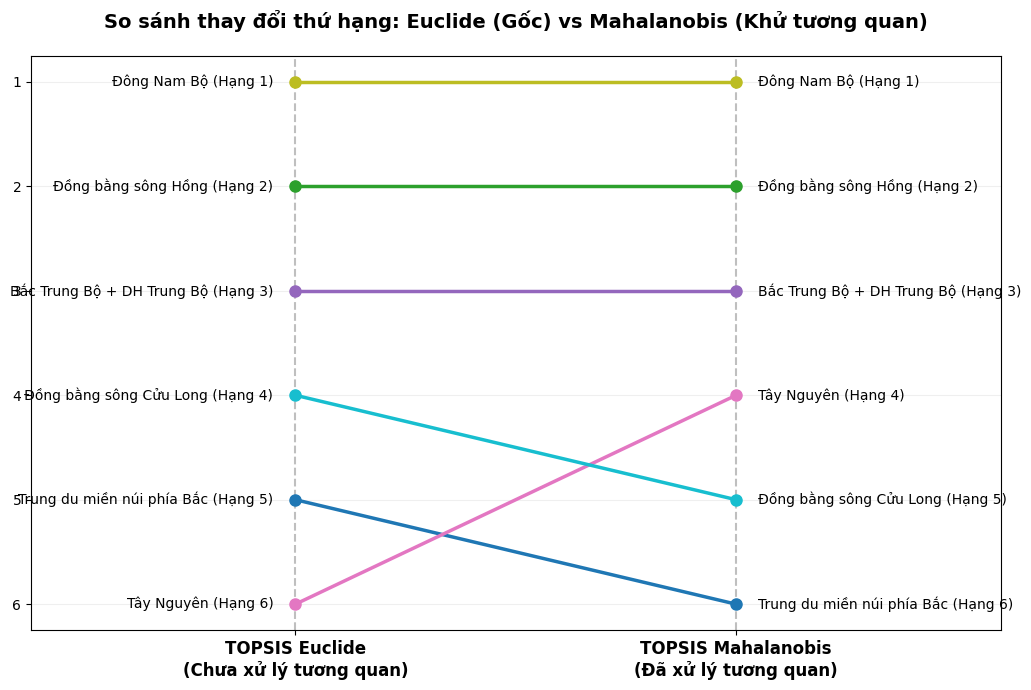


[THÔNG BÁO] Kết quả văn bản: D:\aideom_vn\outputs\so_sanh_euclide_mahalanobis.txt
[THÔNG BÁO] Biểu đồ so sánh: D:\aideom_vn\outputs\so_sanh_xep_hang.png


In [12]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. Khởi tạo dữ liệu trực tiếp từ bảng 6.3 (Source [3, 4])
regions = [
    "Trung du miền núi phía Bắc", "Đồng bằng sông Hồng", 
    "Bắc Trung Bộ + DH Trung Bộ", "Tây Nguyên", 
    "Đông Nam Bộ", "Đồng bằng sông Cửu Long"
]

data = np.array([
    [57.0, 3.5, 38, 22, 21.5, 0.18, 72, 0.405],
    [152.3, 20.0, 78, 68, 36.8, 0.85, 92, 0.358],
    [87.5, 8.2, 55, 40, 27.5, 0.32, 84, 0.372],
    [68.9, 0.8, 32, 18, 18.2, 0.15, 68, 0.412],
    [158.9, 18.5, 82, 75, 42.5, 0.78, 94, 0.385],
    [80.5, 2.1, 48, 30, 16.8, 0.22, 78, 0.392]
])

is_benefit = [True, True, True, True, True, True, True, False]
w = np.array([0.10, 0.10, 0.15, 0.20, 0.15, 0.15, 0.05, 0.10])

# --- BƯỚC CHUẨN BỊ CHUNG ---
norm_matrix = data / np.sqrt((data**2).sum(axis=0))
weighted_matrix = norm_matrix * w
a_star = np.where(is_benefit, weighted_matrix.max(axis=0), weighted_matrix.min(axis=0))
a_neg = np.where(is_benefit, weighted_matrix.min(axis=0), weighted_matrix.max(axis=0))

# --- 1. TOPSIS TRUYỀN THỐNG (EUCLIDE - CÂU 6.4.1) ---
s_star_eucl = np.sqrt(((weighted_matrix - a_star)**2).sum(axis=1))
s_neg_eucl = np.sqrt(((weighted_matrix - a_neg)**2).sum(axis=1))
c_star_eucl = s_neg_eucl / (s_star_eucl + s_neg_eucl)
rank_eucl = pd.Series(c_star_eucl).rank(ascending=False).astype(int).values

# --- 2. TOPSIS MAHALANOBIS ---
cov_matrix = np.cov(weighted_matrix, rowvar=False)
inv_cov_matrix = np.linalg.pinv(cov_matrix)

def mahalanobis_distance(x, y, inv_cov):
    diff = x - y
    return np.sqrt(diff.T @ inv_cov @ diff)

s_star_maha = np.array([mahalanobis_distance(row, a_star, inv_cov_matrix) for row in weighted_matrix])
s_neg_maha = np.array([mahalanobis_distance(row, a_neg, inv_cov_matrix) for row in weighted_matrix])
c_star_maha = s_neg_maha / (s_star_maha + s_neg_maha)
rank_maha = pd.Series(c_star_maha).rank(ascending=False).astype(int).values

# --- 3. XỬ LÝ KẾT QUẢ VÀ LƯU FILE ---
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)

df_compare = pd.DataFrame({
    'Vùng kinh tế': regions,
    'Hạng Euclide (6.4.1)': rank_eucl,
    'Hạng Mahalanobis': rank_maha,
    'Điểm Euclide': c_star_eucl,
    'Điểm Mahalanobis': c_star_maha
}).sort_values(by='Hạng Mahalanobis')

print("--- SO SÁNH XẾP HẠNG: EUCLIDE VS MAHALANOBIS ---")
print(df_compare[['Vùng kinh tế', 'Hạng Euclide (6.4.1)', 'Hạng Mahalanobis']].to_string(index=False))

output_path_txt = os.path.join(output_dir, "so_sanh_euclide_mahalanobis.txt")
with open(output_path_txt, "w", encoding="utf-8") as f:
    f.write(df_compare.to_string(index=False))

# --- 4. VẼ BIỂU ĐỒ ĐƯỜNG DỐC (SLOPE GRAPH) ---
plt.figure(figsize=(11, 7))
plt.title("So sánh thay đổi thứ hạng: Euclide (Gốc) vs Mahalanobis (Khử tương quan)", fontsize=14, pad=20, fontweight='bold')

# Vẽ hai đường trục dọc tại x=0 và x=1
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='grey', linestyle='--', alpha=0.5)

# Thiết lập màu sắc cho các vùng
colors = plt.cm.tab10(np.linspace(0, 1, len(regions)))

for i, region in enumerate(regions):
    y_start = rank_eucl[i]
    y_end = rank_maha[i]
    
    # SỬA LỖI TẠI ĐÂY: Thay [5] thành [0, 1] để vẽ đường nối từ x=0 sang x=1
    plt.plot([0, 1], [y_start, y_end], marker='o', markersize=8, color=colors[i], linewidth=2.5, label=region)
    
    # Thêm text nhãn vùng ở hai đầu cột dốc
    plt.text(-0.05, y_start, f"{region} (Hạng {y_start})", horizontalalignment='right', verticalalignment='center', fontsize=10)
    plt.text(1.05, y_end, f"{region} (Hạng {y_end})", horizontalalignment='left', verticalalignment='center', fontsize=10)

# SỬA LỖI TẠI ĐÂY: Đồng bộ nhãn trục x tại vị trí 0 và 1
plt.xticks([0, 1], ["TOPSIS Euclide\n(Chưa xử lý tương quan)", "TOPSIS Mahalanobis\n(Đã xử lý tương quan)"], fontsize=12, fontweight='bold')
plt.yticks(range(1, 7))
plt.gca().invert_yaxis()  # Hạng 1 nằm trên cùng là chuẩn nhất cho Slope Graph
plt.grid(axis='y', alpha=0.2)
plt.xlim(-0.6, 1.6)
plt.tight_layout()

# Lưu biểu đồ
plot_path = os.path.join(output_dir, "so_sanh_xep_hang.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"\n[THÔNG BÁO] Kết quả văn bản: {os.path.abspath(output_path_txt)}")
print(f"[THÔNG BÁO] Biểu đồ so sánh: {os.path.abspath(plot_path)}")

In [17]:
import numpy as np
import os
from scipy.stats import pearsonr

# 1. Dữ liệu trích xuất trực tiếp từ Bảng 6.3 (Nguồn [1])
# Thứ tự 6 vùng: Trung du miền núi phía Bắc, ĐB sông Hồng, Bắc Trung Bộ & DH miền Trung, Tây Nguyên, Đông Nam Bộ, ĐB sông Cửu Long
ai_readiness = np.array([22, 68, 40, 18, 75, 30])
internet_penetration = np.array([72, 92, 84, 68, 94, 78])

# 2. Tính toán hệ số tương quan Pearson và giá trị p-value
r_coeff, p_value = pearsonr(ai_readiness, internet_penetration)

# 3. In kết quả định lượng ra màn hình
print(f"He so tuong quan Pearson (r): {r_coeff:.4f}")
print(f"Gia tri p-value: {p_value:.4f}")

# 4. Lưu trữ kết quả vào file theo yêu cầu (Phụ lục F1.4 [2])
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "ket_qua_tuong_quan_65c.txt")

with open(output_path, "w", encoding="utf-8") as f:
    f.write("--- KẾT QUẢ XÉT TƯƠNG QUAN GIỨA AI READINESS VÀ INTERNET PENETRATION (CÂU 6.5.c) ---\n")
    f.write(f"Tiêu chí: AI Readiness và Internet penetration\n")
    f.write(f"Hệ số tương quan Pearson (r): {r_coeff:.4f}\n")
    f.write(f"Giá trị p-value: {p_value:.4f}\n")

print(f"\n[THÔNG BÁO] Kết quả đã được lưu thành công tại: {os.path.abspath(output_path)}")

He so tuong quan Pearson (r): 0.9746
Gia tri p-value: 0.0010

[THÔNG BÁO] Kết quả đã được lưu thành công tại: D:\aideom_vn\outputs\ket_qua_tuong_quan_65c.txt
